# Time Series Analysis in AI Java Tutor

**DAT 507 — Scientific Computing Final Project**

This notebook investigates response-time dynamics and learning efficiency across three AI tutoring conditions:
- **Condition 1**: Character-scaffolded tutor
- **Condition 2**: Non-character scaffolded tutor
- **Condition 3**: Direct chat (unstructured)

We focus on time series analysis of student response times within tutoring sessions, examining within-session trends, cross-condition differences, autocorrelation structure, and stationarity.

## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings('ignore')

#sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

CONDITION_NAMES = {1: 'Character Scaffolded', 2: 'Non-Character Scaffolded', 3: 'Direct Chat'}
CONDITION_COLORS = {1: '#2F5D50', 2: '#7BAA9E', 3: '#D4A72C'}




In [ ]:

# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/'
FIG_PATH = '/content/drive/MyDrive/Colab Notebooks/DAT_507_FinalProject_Viz/'

sessions = pd.read_csv(f'{DATA_PATH}sessions.csv')
messages = pd.read_csv(f'{DATA_PATH}messages.csv')

print(f'Sessions: {sessions.shape}')
print(f'Messages: {messages.shape}')
print(f'\nSession columns: {list(sessions.columns)}')
print(f'Message columns: {list(messages.columns)}')

Mounted at /content/drive
Sessions: (136, 17)
Messages: (2874, 7)

Session columns: ['user_id', 'session_type', 'status', 'condition', 'start_time', 'end_time', 'duration_seconds', 'total_messages', 'user_messages', 'assistant_messages', 'quiz_score', 'quiz_total', 'quiz_percentage', 'quiz_completed_time', 'survey_completed_time', 'avg_difficulty_correct', 'avg_difficulty_incorrect']
Message columns: ['user_id', 'session_type', 'message_id', 'role', 'timestamp', 'content_length', 'content']


In [ ]:
# Filter to completed sessions only
sessions = sessions[sessions['status'] == 'completed'].copy()
print(f'Completed sessions: {len(sessions)}')
print(f'\nCondition distribution:')
print(sessions['condition'].value_counts().sort_index())
print(f'\nSession type distribution:')
print(sessions['session_type'].value_counts())


Completed sessions: 115

Condition distribution:
condition
1.0    41
2.0    39
3.0    35
Name: count, dtype: int64

Session type distribution:
session_type
arraylist    63
recursion    52
Name: count, dtype: int64


## 2. Response Time Engineering

We compute the time elapsed between consecutive messages within each user-session pair. This gives us a per-message response time series that captures the pacing of the student-tutor interaction.

In [ ]:
# Sort messages chronologically within each session
messages = messages.sort_values(['user_id', 'session_type', 'message_id']).copy()

# Compute inter-message time (seconds between consecutive messages in a session)
messages['response_time'] = messages.groupby(['user_id', 'session_type'])['timestamp'].diff()

# Filter to user messages only for student response times
user_msgs = messages[messages['role'] == 'user'].copy()
#print("User messages: " + str(len(user_msgs))

# Remove extreme outliers (> 5 minutes between messages likely indicates distraction)
user_msgs = user_msgs[user_msgs['response_time'].between(1, 300)].copy()

print(f'User messages with valid response times: {len(user_msgs)}')
print(f'\nResponse time summary (seconds):')
print(user_msgs['response_time'].describe())

User messages with valid response times: 1381

Response time summary (seconds):
count    1381.000000
mean       38.730512
std        35.679069
min         1.393283
25%        13.814218
50%        27.809597
75%        52.193481
max       262.607169
Name: response_time, dtype: float64


In [ ]:
# Merge condition info onto messages
user_msgs = user_msgs.merge(
    sessions[['user_id', 'session_type', 'condition', 'quiz_percentage']],
    on=['user_id', 'session_type'],
    how='left'
)
user_msgs['condition_name'] = user_msgs['condition'].map(CONDITION_NAMES)

print(f'Messages per condition:')
print(user_msgs.groupby('condition_name')['response_time'].count())

Messages per condition:
condition_name
Character Scaffolded        421
Direct Chat                 545
Non-Character Scaffolded    397
Name: response_time, dtype: int64


### 2.1 Response Time Distributions by Condition

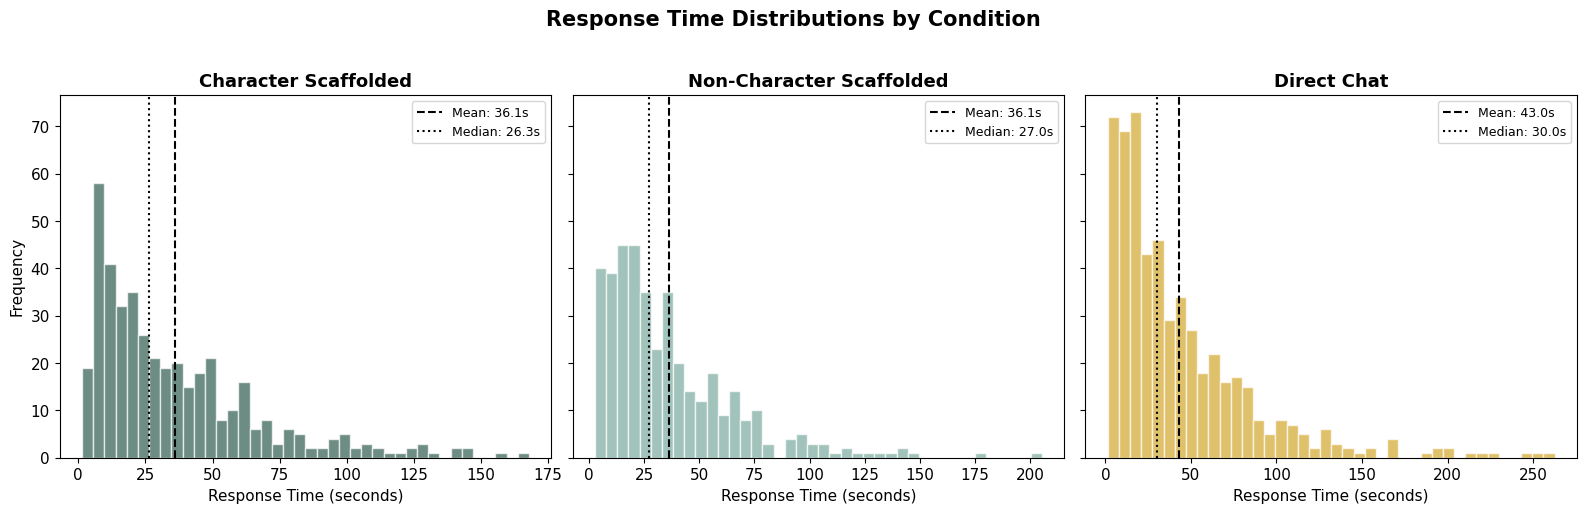

<Figure size 1200x600 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, (cond, name) in enumerate(CONDITION_NAMES.items()):
    data = user_msgs[user_msgs['condition'] == cond]['response_time']
    axes[i].hist(data, bins=40, color=CONDITION_COLORS[cond], alpha=0.7, edgecolor='white')
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}s')
    axes[i].axvline(data.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.1f}s')
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Response Time (seconds)')
    axes[i].legend(fontsize=9)

axes[0].set_ylabel('Frequency')
fig.suptitle('Response Time Distributions by Condition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rt_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig(f'{FIG_PATH}/rt_distributions.png', dpi=300)

In [ ]:
# Summary statistics table
rt_stats = user_msgs.groupby('condition_name')['response_time'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

# Add coefficient of variation and IQR
rt_stats['cv'] = (rt_stats['std'] / rt_stats['mean']).round(3)
rt_stats['iqr'] = user_msgs.groupby('condition_name')['response_time'].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(2)

print('Response Time Summary Statistics by Condition')
print('=' * 80)
print(rt_stats.to_string())

## 3. Hypothesis Testing

Before diving into time series analysis, we run a quick set of hypothesis tests to establish whether conditions differ in quiz performance and response time behavior.

### 3.1 ANOVA: Quiz Performance Across Conditions

In [ ]:
# One-way ANOVA on quiz_percentage across conditions
groups = [sessions[sessions['condition'] == c]['quiz_percentage'].dropna() for c in [1, 2, 3]]
f_stat, p_value = stats.f_oneway(*groups)

print('H0: Mean quiz performance is equal across all three conditions.')
print(f'F-statistic: {f_stat:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'Result: {"Reject H0" if p_value < 0.05 else "Fail to reject H0"} at alpha = 0.05')

# Effect size (eta-squared)
grand_mean = sessions['quiz_percentage'].dropna().mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = sum((sessions['quiz_percentage'].dropna() - grand_mean)**2)
eta_sq = ss_between / ss_total
print(f'Effect size (eta-squared): {eta_sq:.4f}')

In [ ]:
# Box plot of quiz performance
fig, ax = plt.subplots(figsize=(8, 5))
bp_data = [sessions[sessions['condition'] == c]['quiz_percentage'].dropna() for c in [1, 2, 3]]
bp = ax.boxplot(bp_data, labels=[CONDITION_NAMES[c] for c in [1, 2, 3]], patch_artist=True)

for patch, color in zip(bp['boxes'], [CONDITION_COLORS[c] for c in [1, 2, 3]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Quiz Percentage')
ax.set_title('Quiz Performance by Condition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH+'quiz_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Kruskal-Wallis: Response Time Across Conditions

Response times are heavily right-skewed, so we use a non-parametric test.

In [ ]:
rt_groups = [user_msgs[user_msgs['condition'] == c]['response_time'].dropna() for c in [1, 2, 3]]
h_stat, p_value_kw = stats.kruskal(*rt_groups)

print('H0: Response time distributions are equal across all three conditions.')
print(f'H-statistic: {h_stat:.4f}')
print(f'p-value: {p_value_kw:.4f}')
print(f'Result: {"Reject H0" if p_value_kw < 0.05 else "Fail to reject H0"} at alpha = 0.05')

### 3.3 Bootstrap: Mean Response Time Difference (Scaffolded vs. Direct Chat)

In [ ]:
def bootstrap_mean_diff(group_a, group_b, n_boot=10000, seed=42):
    """Bootstrap the difference in means between two groups."""
    rng = np.random.default_rng(seed)
    a = np.array(group_a)
    b = np.array(group_b)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        boot_a = rng.choice(a, size=len(a), replace=True)
        boot_b = rng.choice(b, size=len(b), replace=True)
        diffs[i] = boot_a.mean() - boot_b.mean()
    return diffs

# Aggregate to session-level mean response times
session_rt = user_msgs.groupby(['user_id', 'session_type', 'condition'])['response_time'].mean().reset_index()

scaffolded_rt = session_rt[session_rt['condition'].isin([1, 2])]['response_time'].values
direct_rt = session_rt[session_rt['condition'] == 3]['response_time'].values

boot_diffs = bootstrap_mean_diff(scaffolded_rt, direct_rt)
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
observed_diff = scaffolded_rt.mean() - direct_rt.mean()

print(f'Observed difference (scaffolded - direct): {observed_diff:.2f} seconds')
print(f'95% Bootstrap CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
print(f'CI excludes zero: {ci_lower > 0 or ci_upper < 0}')

fig, ax = plt.subplots(figsize=(8, 4))
# ax.hist(boot_diffs, bins=60, color='#3498db', alpha=0.7, edgecolor='white')
# ax.axvline(observed_diff, color='red', linewidth=2, label=f'Observed: {observed_diff:.2f}s')
# ax.axvline(ci_lower, color='black', linestyle='--', linewidth=1, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
# ax.axvline(ci_upper, color='black', linestyle='--', linewidth=1)
# ax.axvline(0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
# ax.set_xlabel('Difference in Mean Response Time (seconds)')
# ax.set_ylabel('Frequency')
# ax.set_title('Bootstrap Distribution: Scaffolded vs Direct Chat Response Time', fontweight='bold')
# ax.legend()
# plt.tight_layout()
# plt.savefig(FIG_PATH+'bootstrap_rt_diff.png', dpi=150, bbox_inches='tight')
# plt.show()
# Bootstrap histogram (use sage for the distribution)
ax.hist(
    boot_diffs,
    bins=60,
    color=CONDITION_COLORS[2],   # sage / muted teal
    alpha=0.7,
    edgecolor='white'
)

# Observed difference (use gold for emphasis)
ax.axvline(
    observed_diff,
    color=CONDITION_COLORS[3],    # gold
    linewidth=2,
    label=f'Observed: {observed_diff:.2f}s'
)

# Confidence interval bounds (use forest green for structure)
ax.axvline(
    ci_lower,
    color=CONDITION_COLORS[1],      # forest green
    linestyle='--',
    linewidth=1,
    label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]'
)

ax.axvline(
    ci_upper,
    color=CONDITION_COLORS[1],   # forest green
    linestyle='--',
    linewidth=1
)


# Zero reference line (neutral gray is fine)
ax.axvline(
    0,
    color='gray',
    linestyle=':',
    linewidth=1,
    alpha=0.7
)

ax.set_xlabel('Difference in Mean Response Time (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution: Scaffolded vs Direct Chat Response Time', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_PATH + 'bootstrap_rt_diff.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Within-Session Response Time Trends

A key question: **do students speed up or slow down as a session progresses?**

We normalize each session's message sequence to a 0-1 scale (session progress) and fit linear trends to the response times.

In [ ]:
# Add a normalized position within each session (0 = start, 1 = end)
def add_session_progress(df):
    """Add a normalized progress column (0 to 1) within each user-session."""
    df = df.copy()
    df['msg_order'] = df.groupby(['user_id', 'session_type']).cumcount()
    df['msg_total'] = df.groupby(['user_id', 'session_type'])['msg_order'].transform('max')
    df['session_progress'] = df['msg_order'] / df['msg_total'].replace(0, 1)
    return df

user_msgs = add_session_progress(user_msgs)

# Fit a linear slope to each session's response times
def compute_rt_slope(group):
    """Compute the linear slope of response times within a session."""
    if len(group) < 3:
        return np.nan
    x = np.arange(len(group))
    y = group['response_time'].values
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope

session_slopes = user_msgs.groupby(['user_id', 'session_type', 'condition']).apply(compute_rt_slope).reset_index()
session_slopes.columns = ['user_id', 'session_type', 'condition', 'rt_slope']
session_slopes['condition_name'] = session_slopes['condition'].map(CONDITION_NAMES)
session_slopes = session_slopes.dropna(subset=['rt_slope'])

print('Response Time Slope by Condition (negative = speeding up, positive = slowing down)')
print('=' * 70)
print(session_slopes.groupby('condition_name')['rt_slope'].agg(['mean', 'median', 'std']).round(4).to_string())

In [ ]:
# Visualize: average response time trajectory across session progress
# Bin session progress into deciles
user_msgs['progress_bin'] = pd.cut(user_msgs['session_progress'], bins=10, labels=False) / 9

fig, ax = plt.subplots(figsize=(10, 6))

for cond in [1, 2, 3]:
    subset = user_msgs[user_msgs['condition'] == cond]
    trajectory = subset.groupby('progress_bin')['response_time'].mean()
    ax.plot(trajectory.index, trajectory.values,
            marker='o', linewidth=2, markersize=6,
            color=CONDITION_COLORS[cond], label=CONDITION_NAMES[cond])

ax.set_xlabel('Session Progress (0 = start, 1 = end)', fontsize=12)
ax.set_ylabel('Mean Response Time (seconds)', fontsize=12)
ax.set_title('Response Time Trajectory Across Session Progress', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(FIG_PATH+'rt_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Distribution of slopes by condition
fig, ax = plt.subplots(figsize=(9, 5))

for cond in [1, 2, 3]:
    slopes = session_slopes[session_slopes['condition'] == cond]['rt_slope']
    ax.hist(slopes, bins=20, alpha=0.5, color=CONDITION_COLORS[cond],
            label=f'{CONDITION_NAMES[cond]} (mean={slopes.mean():.3f})', edgecolor='white')

ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('Response Time Slope (seconds per message)')
ax.set_ylabel('Number of Sessions')
ax.set_title('Distribution of Within-Session Response Time Slopes', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH+'rt_slopes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# One-sample t-test: is the mean slope significantly different from zero?
print('One-sample t-test: Is the mean RT slope significantly different from zero?')
print('=' * 70)
for cond in [1, 2, 3]:
    slopes = session_slopes[session_slopes['condition'] == cond]['rt_slope'].dropna()
    t_stat, p_val = stats.ttest_1samp(slopes, 0)
    direction = 'speeding up' if slopes.mean() < 0 else 'slowing down'
    print(f'{CONDITION_NAMES[cond]:30s} | mean slope: {slopes.mean():+.4f} | t={t_stat:.3f} | p={p_val:.4f} | {direction}')

## 5. Response Time Stability Metrics

Beyond trends, we examine **variability** in response times within sessions. High variability may indicate inconsistent engagement, while stable response times suggest sustained focus.

In [ ]:
# Compute per-session stability metrics
def session_stability_metrics(group):
    rt = group['response_time'].dropna().values
    if len(rt) < 3:
        return pd.Series([np.nan] * 5, index=['rt_mean', 'rt_std', 'rt_cv', 'rt_mad', 'rt_iqr'])
    return pd.Series({
        'rt_mean': np.mean(rt),
        'rt_std': np.std(rt, ddof=1),
        'rt_cv': np.std(rt, ddof=1) / np.mean(rt) if np.mean(rt) > 0 else np.nan,
        'rt_mad': np.median(np.abs(rt - np.median(rt))),
        'rt_iqr': np.percentile(rt, 75) - np.percentile(rt, 25)
    })

stability = user_msgs.groupby(['user_id', 'session_type', 'condition']).apply(session_stability_metrics).reset_index()
stability['condition_name'] = stability['condition'].map(CONDITION_NAMES)
stability = stability.dropna(subset=['rt_mean'])

print('Response Time Stability Metrics by Condition')
print('=' * 80)
print(stability.groupby('condition_name')[['rt_mean', 'rt_std', 'rt_cv', 'rt_mad', 'rt_iqr']].mean().round(3).to_string())

In [ ]:
# Visualize stability: CV by condition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV distribution
for cond in [1, 2, 3]:
    data = stability[stability['condition'] == cond]['rt_cv'].dropna()
    axes[0].hist(data, bins=15, alpha=0.5, color=CONDITION_COLORS[cond],
                 label=CONDITION_NAMES[cond], edgecolor='white')

axes[0].set_xlabel('Coefficient of Variation')
axes[0].set_ylabel('Number of Sessions')
axes[0].set_title('Response Time Variability (CV)', fontsize=13, fontweight='bold')
axes[0].legend()

# Mean RT vs CV scatter
for cond in [1, 2, 3]:
    sub = stability[stability['condition'] == cond]
    axes[1].scatter(sub['rt_mean'], sub['rt_cv'], alpha=0.6, s=50,
                    color=CONDITION_COLORS[cond], label=CONDITION_NAMES[cond])

axes[1].set_xlabel('Mean Response Time (seconds)')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].set_title('Mean Response Time vs Variability', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_PATH+'rt_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Autocorrelation Analysis

We examine the autocorrelation structure of response time sequences to understand whether response times exhibit serial dependence — i.e., whether a fast response tends to follow a fast response (positive autocorrelation) or alternate (negative).

In [ ]:
# Select sessions with enough messages for meaningful ACF
session_lengths = user_msgs.groupby(['user_id', 'session_type']).size()
long_sessions = session_lengths[session_lengths >= 10].reset_index()
long_sessions.columns = ['user_id', 'session_type', 'n_messages']

print(f'Sessions with 10+ user messages: {len(long_sessions)}')

# Compute lag-1 autocorrelation for each session
def lag1_autocorr(group):
    rt = group['response_time'].dropna().values
    if len(rt) < 5:
        return np.nan
    return pd.Series(rt).autocorr(lag=1)

autocorrs = user_msgs.groupby(['user_id', 'session_type', 'condition']).apply(lag1_autocorr).reset_index()
autocorrs.columns = ['user_id', 'session_type', 'condition', 'lag1_acf']
autocorrs['condition_name'] = autocorrs['condition'].map(CONDITION_NAMES)
autocorrs = autocorrs.dropna(subset=['lag1_acf'])

print('\nLag-1 Autocorrelation by Condition')
print('=' * 60)
print(autocorrs.groupby('condition_name')['lag1_acf'].agg(['mean', 'median', 'std']).round(4).to_string())

In [ ]:
# Plot ACF for example sessions (one per condition)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, cond in enumerate([1, 2, 3]):
    # Pick a session with enough messages
    cond_sessions = user_msgs[user_msgs['condition'] == cond].groupby(
        ['user_id', 'session_type']).size().reset_index(name='n')
    cond_sessions = cond_sessions[cond_sessions['n'] >= 10]

    if len(cond_sessions) == 0:
        axes[i].set_title(f'{CONDITION_NAMES[cond]} (insufficient data)')
        continue

    example = cond_sessions.iloc[0]
    rt_series = user_msgs[
        (user_msgs['user_id'] == example['user_id']) &
        (user_msgs['session_type'] == example['session_type'])
    ]['response_time'].dropna().values

    max_lags = min(len(rt_series) // 2 - 1, 15)
    if max_lags >= 1:
        plot_acf(rt_series, lags=max_lags, ax=axes[i], color=CONDITION_COLORS[cond],
                 title=f'{CONDITION_NAMES[cond]}', alpha=0.05)

fig.suptitle('Example Autocorrelation Functions (ACF) by Condition', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIG_PATH+'acf_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Distribution of lag-1 autocorrelations
fig, ax = plt.subplots(figsize=(9, 5))

for cond in [1, 2, 3]:
    data = autocorrs[autocorrs['condition'] == cond]['lag1_acf']
    ax.hist(data, bins=20, alpha=0.5, color=CONDITION_COLORS[cond],
            label=f'{CONDITION_NAMES[cond]} (mean={data.mean():.3f})', edgecolor='white')

ax.axvline(0, color='black', linestyle=':', linewidth=1)
ax.set_xlabel('Lag-1 Autocorrelation')
ax.set_ylabel('Number of Sessions')
ax.set_title('Distribution of Lag-1 Autocorrelation in Response Times', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH+'lag1_acf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Moving Average Smoothing & Trend Decomposition

We apply moving average smoothing to visualize underlying response time trends, filtering out message-to-message noise.

In [ ]:
# Smooth short-term noise in the response-time signal
def moving_average(series, window=3):
    """Apply a moving average filter to the response time series."""
    return pd.Series(series)
    .rolling(window=window, min_periods=1, center=True)
    .mean().values


# Plot example sessions with raw + smoothed response times
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cond in enumerate([1, 2, 3]):
    cond_data = user_msgs[user_msgs['condition'] == cond]
    session_sizes = cond_data.groupby(['user_id', 'session_type']).size()
    session_sizes = session_sizes[session_sizes >= 8]

    if len(session_sizes) == 0:
        continue

    # Pick the session closest to median length
    median_len = session_sizes.median()
    best_session = session_sizes.iloc[(session_sizes - median_len).abs().argsort()[:1]]
    uid, stype = best_session.index[0]

    rt = cond_data[
        (cond_data['user_id'] == uid) & (cond_data['session_type'] == stype)
    ]['response_time'].dropna().values

    x = np.arange(len(rt))
    smoothed = moving_average(rt, window=3)

    axes[i].scatter(x, rt, alpha=0.4, s=30, color=CONDITION_COLORS[cond], label='Raw')
    axes[i].plot(x, smoothed, color=CONDITION_COLORS[cond], linewidth=2, label='MA(3)')

    # Add linear trend
    slope, intercept, _, _, _ = stats.linregress(x, rt)
    axes[i].plot(x, intercept + slope * x, '--', color='black', linewidth=1,
                 label=f'Trend (slope={slope:.2f})')

    axes[i].set_title(f'{CONDITION_NAMES[cond]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Message Number')
    axes[i].set_ylabel('Response Time (s)')
    axes[i].legend(fontsize=9)

fig.suptitle('Example Sessions: Raw Response Times with Moving Average & Trend',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIG_PATH+'rt_smoothing_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Time Series Forecasting

We fit autoregressive (AR) and ARIMA models to individual session response time sequences to evaluate whether response times are predictable within a session. High predictability would suggest systematic engagement patterns.


In [ ]:
def fit_ar_model(rt_series, lags=2):
    """Fit an AR model and return in-sample R-squared and residual std."""
    if len(rt_series) < lags + 5:
        return np.nan, np.nan
    try:
        model = AutoReg(rt_series, lags=lags, old_names=False).fit()
        # Compute R-squared manually
        fitted = model.fittedvalues
        actual = rt_series[lags:]
        ss_res = np.sum((actual - fitted) ** 2)
        ss_tot = np.sum((actual - actual.mean()) ** 2)
        r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return r_squared, model.sigma2 ** 0.5
    except:
        return np.nan, np.nan

# Fit AR(2) to each session
ar_results = []
for (uid, stype, cond), group in user_msgs.groupby(['user_id', 'session_type', 'condition']):
    rt = group['response_time'].dropna().values
    r2, resid_std = fit_ar_model(rt, lags=2)
    ar_results.append({
        'user_id': uid, 'session_type': stype, 'condition': cond,
        'ar_r2': r2, 'ar_resid_std': resid_std, 'n_messages': len(rt)
    })

ar_df = pd.DataFrame(ar_results).dropna(subset=['ar_r2'])
ar_df['condition_name'] = ar_df['condition'].map(CONDITION_NAMES)

print('AR(2) Model Fit by Condition')
print('=' * 70)
print(ar_df.groupby('condition_name')[['ar_r2', 'ar_resid_std']].agg(['mean', 'median']).round(4).to_string())

## 9. Response Time vs Learning Outcomes

Finally, we examine whether response time characteristics are associated with quiz performance.

In [ ]:
# Merge stability metrics with quiz performance
analysis_df = stability.merge(
    sessions[['user_id', 'session_type', 'quiz_percentage', 'duration_seconds', 'total_messages']],
    on=['user_id', 'session_type'],
    how='left'
)

# Add slopes
analysis_df = analysis_df.merge(
    session_slopes[['user_id', 'session_type', 'rt_slope']],
    on=['user_id', 'session_type'],
    how='left'
)

# Add autocorrelation
analysis_df = analysis_df.merge(
    autocorrs[['user_id', 'session_type', 'lag1_acf']],
    on=['user_id', 'session_type'],
    how='left'
)

analysis_df = analysis_df.dropna(subset=['quiz_percentage'])
print(f'Analysis dataset: {len(analysis_df)} sessions')
print(f'\nCorrelation with quiz_percentage:')
print('=' * 50)

corr_vars = ['rt_mean', 'rt_std', 'rt_cv', 'rt_mad', 'rt_iqr', 'rt_slope', 'lag1_acf']
for var in corr_vars:
    valid = analysis_df[['quiz_percentage', var]].dropna()
    if len(valid) > 5:
        r, p = stats.pearsonr(valid['quiz_percentage'], valid[var])
        sig = '*' if p < 0.05 else ''
        print(f'  {var:15s}  r = {r:+.4f}  p = {p:.4f} {sig}')

In [ ]:
# Scatter matrix of key relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_configs = [
    ('rt_mean', 'Mean Response Time (s)'),
    ('rt_cv', 'Response Time CV'),
    ('rt_slope', 'RT Slope (s/msg)'),
    ('lag1_acf', 'Lag-1 Autocorrelation')
]

for ax, (var, label) in zip(axes.flat, plot_configs):
    for cond in [1, 2, 3]:
        sub = analysis_df[analysis_df['condition'] == cond]
        ax.scatter(sub[var], sub['quiz_percentage'], alpha=0.5, s=40,
                   color=CONDITION_COLORS[cond], label=CONDITION_NAMES[cond])

    # Overall trend line
    valid = analysis_df[[var, 'quiz_percentage']].dropna()
    if len(valid) > 5:
        z = np.polyfit(valid[var], valid['quiz_percentage'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[var].min(), valid[var].max(), 100)
        ax.plot(x_line, p(x_line), '--', color='black', alpha=0.5, linewidth=1)

    ax.set_xlabel(label)
    ax.set_ylabel('Quiz Percentage')
    ax.legend(fontsize=8)

fig.suptitle('Response Time Characteristics vs Quiz Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH+'rt_vs_quiz.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. Signal and Frequency

In [ ]:
messages = messages.merge(
    sessions[['user_id', 'session_type', 'condition']],
    on=['user_id', 'session_type'],
    how='left'
)
messages.head()
messages['condition'].value_counts(dropna=False)
messages.dropna(subset=['response_time'], inplace=True)

In [ ]:

from scipy.fft import rfft, rfftfreq

# Compute FFT magnitude spectrum for a single session
def compute_fft(signal):
    """
    Compute the FFT magnitude spectrum for a single session's
    response-time signal. Returns (freqs, magnitude).
    """
    signal = signal.dropna().values
    if len(signal) < 4:   # too short for FFT to be meaningful
        return None, None

    n = len(signal)
    freqs = rfftfreq(n, d=1)  # treat each message as 1 unit apart
    centered = signal - signal.mean()
    fft_vals = rfft(centered)
    magnitude = np.abs(fft_vals)

    return freqs, magnitude


# Loop through sessions and map to condition
fft_by_condition = {}



grouped = messages.groupby(["condition", "user_id", "session_type"])

for (cond, uid, stype), df in grouped:
    df = df.sort_values("message_id")
    freqs, mag = compute_fft(df["response_time"])

    if freqs is None:
        continue

    if cond not in fft_by_condition:
        fft_by_condition[cond] = []

    # store magnitude, but we need them aligned later
    fft_by_condition[cond].append((freqs, mag))

# ---------------------------------------------------------
# 3. Align FFT lengths (sessions have different lengths)
#    → truncate to the minimum length per condition
# ---------------------------------------------------------
avg_freqs = {}
avg_mags = {}

for cond, spectra in fft_by_condition.items():
    # find smallest FFT length in this condition
    min_len = min(len(mag) for (_, mag) in spectra)

    # truncate and stack
    mags = np.stack([mag[:min_len] for (_, mag) in spectra])
    freqs = spectra[0][0][:min_len]

    avg_freqs[cond] = freqs
    avg_mags[cond] = mags.mean(axis=0)

# ---------------------------------------------------------
# 4. Plot averaged FFT per condition
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.figure(figsize=(12, 6))

for cond in sorted(avg_mags.keys()):
    plt.plot(
        avg_freqs[cond],
        avg_mags[cond],
        label=CONDITION_NAMES[cond],
        color=CONDITION_COLORS[cond],
        linewidth=2.2
    )

plt.title("Average Frequency Spectrum by Condition")
plt.xlabel("Frequency (cycles per response)")
plt.ylabel("Magnitude")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_PATH + 'fft_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(messages['response_time'].describe())
print(messages['response_time'].isna().sum())
messages['response_time'].unique()[:10]


## 11. Summary of Findings

In [ ]:
print('=' * 70)
print('SUMMARY OF FINDINGS')
print('=' * 70)

print('\n1. HYPOTHESIS TESTING')
print('-' * 40)
print(f'   ANOVA (quiz ~ condition): F={f_stat:.3f}, p={p_value:.4f}, eta²={eta_sq:.4f}')
print(f'   Kruskal-Wallis (RT ~ condition): H={h_stat:.3f}, p={p_value_kw:.4f}')
print(f'   Bootstrap RT diff (scaffolded-direct): {observed_diff:.2f}s, 95% CI [{ci_lower:.2f}, {ci_upper:.2f}]')

print('\n2. WITHIN-SESSION TRENDS')
print('-' * 40)
for cond in [1, 2, 3]:
    slopes = session_slopes[session_slopes['condition'] == cond]['rt_slope']
    direction = 'speed up' if slopes.mean() < 0 else 'slow down'
    print(f'   {CONDITION_NAMES[cond]:30s} | mean slope: {slopes.mean():+.4f} s/msg ({direction})')

print('\n3. RESPONSE TIME STABILITY')
print('-' * 40)
for cond in [1, 2, 3]:
    cv = stability[stability['condition'] == cond]['rt_cv'].mean()
    print(f'   {CONDITION_NAMES[cond]:30s} | mean CV: {cv:.3f}')

print('\n4. AUTOCORRELATION')
print('-' * 40)
for cond in [1, 2, 3]:
    acf_mean = autocorrs[autocorrs['condition'] == cond]['lag1_acf'].mean()
    print(f'   {CONDITION_NAMES[cond]:30s} | mean lag-1 ACF: {acf_mean:+.4f}')

print('\n5. KEY CORRELATIONS WITH QUIZ PERFORMANCE')
print('-' * 40)
for var in corr_vars:
    valid = analysis_df[['quiz_percentage', var]].dropna()
    if len(valid) > 5:
        r, p = stats.pearsonr(valid['quiz_percentage'], valid[var])
        if p < 0.1:
            print(f'   {var:15s}  r={r:+.4f}  p={p:.4f} {"*" if p < 0.05 else "(trend)"}')

print('\n' + '=' * 70)